# Self-attention in PyTorch

The hand calculation becomes a reusable module. The implementation keeps `(batch, time, channels)` visible and checks that a causal mask prevents future information from entering earlier outputs.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
class CausalSelfAttention(nn.Module):
    def __init__(self, channels, max_time):
        super().__init__()
        self.query = nn.Linear(channels, channels, bias=False)
        self.key = nn.Linear(channels, channels, bias=False)
        self.value = nn.Linear(channels, channels, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(max_time, max_time, dtype=torch.bool)))

    def forward(self, x):
        batch, time, channels = x.shape
        q, k, v = self.query(x), self.key(x), self.value(x)
        scores = q @ k.transpose(-2,-1) / math.sqrt(channels)
        scores = scores.masked_fill(~self.mask[:time,:time], float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        return weights @ v, weights

attention = CausalSelfAttention(channels=8, max_time=6).to(DEVICE)
x = torch.randn(2, 6, 8, device=DEVICE)
y, weights = attention(x)
print("input:", tuple(x.shape), "output:", tuple(y.shape), "weights:", tuple(weights.shape))
assert torch.allclose(weights.triu(1), torch.zeros_like(weights.triu(1)))

input: (2, 6, 8) output: (2, 6, 8) weights: (2, 6, 6)


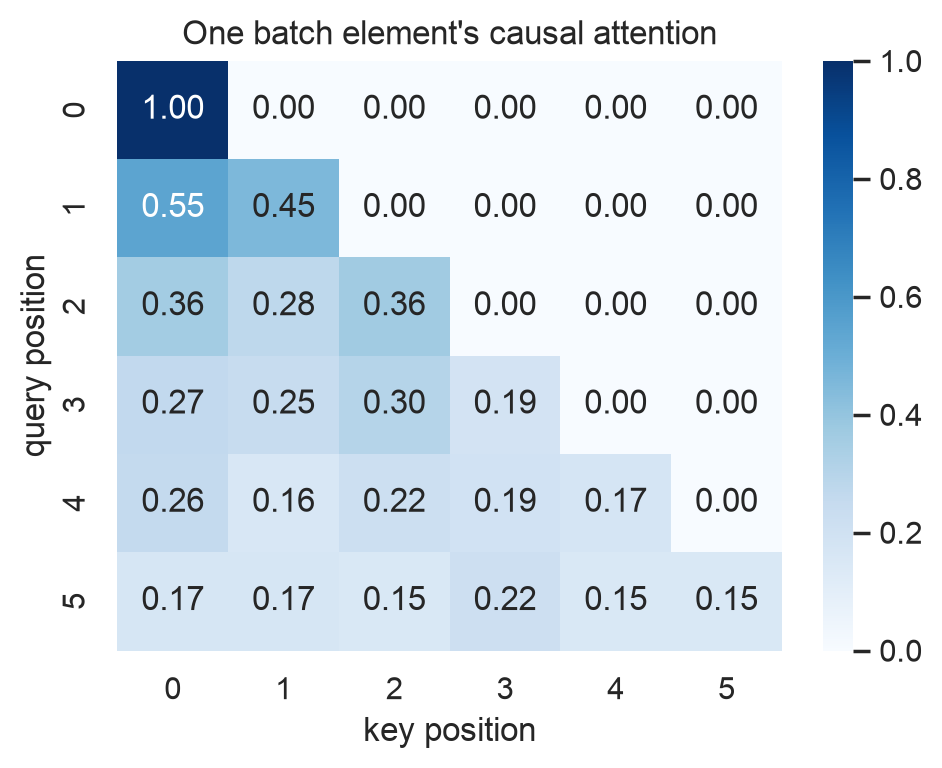

In [3]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(weights[0].detach().cpu(), vmin=0, vmax=1, cmap="Blues", annot=True, fmt=".2f", ax=ax)
ax.set(title="One batch element's causal attention", xlabel="key position", ylabel="query position")
plt.tight_layout(); plt.show()

To test causality, change a future token while holding earlier tokens fixed. The outputs at earlier positions should remain unchanged; the output at and after the changed position may change.

In [4]:
modified = x.clone(); modified[:, 5] += 20
y_modified, _ = attention(modified)
print("maximum change at positions 0–4:", (y_modified[:,:5] - y[:,:5]).abs().max().item())
print("change at final position:", (y_modified[:,5] - y[:,5]).abs().mean().item())

maximum change at positions 0–4: 0.0
change at final position: 0.35589054226875305


## From equations to tensors

The hand calculation uses a `(time, channels)` matrix. PyTorch adds a batch axis, so the input is `(batch, time, channels)`. The score matrix is `(batch, time, time)`: the last two axes compare every query position with every key position. The value aggregation preserves `(batch, time, channels)`, which is why attention can be inserted into a residual stream.

## Two implementation details

The causal mask is registered as a buffer so it moves with the module but is not optimized. The `-inf` entries are applied before softmax; their probability becomes zero. Both details are small, but missing either one produces a model that is easy to run and mathematically wrong.

## What the intervention tests

Changing a future token must not change earlier outputs. This is a stronger check than inspecting the mask visually: it tests the complete path from the input through projections, masking, softmax, and value aggregation.

The module now performs content-dependent routing, but one head has one set of projections. Multi-head attention gives the model several smaller routing spaces that can specialize in different relationships.